# This study employs multi-linear regression to predict the price of the S&P 500 using multiple economic variables, including oil prices, industrial production, export-import levels, retail sales, consumer confidence, and dollar strength. Historical economic data was used to train the model, enabling it to learn the relationships between these variables and the S&P 500 price. To address multicollinearity, Principal Component Analysis (PCA) was applied.  L2 regularization - Ridge regression was also used. After validation and testing, the model indicates that the S&P 500 is currently overvalued.



# This approach demonstrates the effectiveness of combining multiple economic indicators and regularization techniques for financial market prediction.

## This code gets historical data for economic variables and SNP 500. It uses yahoo finance library

In [ ]:
import pandas as pd
import yfinance as yf
import pandas_datareader as pdr
from datetime import datetime, timedelta

def fetch_economic_market_data(start_date='2000-01-01', end_date=None):
    if end_date is None:
        end_date = datetime.now().strftime('%Y-%m-%d')

    dfs = {}

    # Market-based variables
    market_symbols = {
        'S&P 500': '^GSPC',
        'Oil Price': 'CL=F',
        'Gold Price': 'GC=F',
        'USD Index': 'DX=F',
        'Copper Price': 'HG=F',
        'Maersk Stock': 'MAERSK-B.CO',  # Major shipping company as proxy
        'Kuehne + Nagel': 'KNIN.SW',    # Major logistics company as proxy
        'VIX': '^VIX',                  # Volatility Index
        'Natural Gas': 'NG=F',          # Natural Gas Price
        'Wheat': 'ZW=F',                # Wheat Price
        'Corn': 'ZC=F',                 # Corn Price
    }

    for name, symbol in market_symbols.items():
        try:
            ticker = yf.Ticker(symbol)
            data = ticker.history(start=start_date, end=end_date)
            if len(data) > 0:
                if 'Close' in data.columns:
                    # Convert tz-aware to tz-naive
                    data.index = data.index.tz_localize(None)
                    dfs[name] = data['Close']
                else:
                    print(f"Warning: No Close price found for {name}")
            else:
                print(f"Warning: No data retrieved for {name}")
        except Exception as e:
            print(f"Error fetching {name}: {e}")

    # Economic data from FRED
    fred_symbols = {
        '10-Yr Treasury Yield': 'DGS10',
        '2-Yr Treasury Yield': 'DGS2',
        'Unemployment Rate': 'UNRATE',
        'CPI (Inflation)': 'CPIAUCSL',
        'Industrial Production': 'INDPRO',
        'Housing Starts': 'HOUST',
        'Trade Balance': 'BOPGSTB',      # Monthly trade balance
        'Export Price Index': 'IR',       # Export price index
        'Import Price Index': 'IQ',
        'Fed Interest Rate': 'FEDFUNDS',
        'Dollars in Circulation': 'CURRCIR',  # Currency in circulation
        'GDP Growth': 'GDP',              # Quarterly GDP growth
        'Consumer Confidence': 'UMCSENT', # Consumer Confidence Index
        'Retail Sales': 'RSAFS',          # Retail Sales
        'PCE Inflation': 'PCE',           # Personal Consumption Expenditures
        'M2 Money Supply': 'M2SL',        # M2 Money Supply
    }

    for name, symbol in fred_symbols.items():
        try:
            data = pdr.DataReader(symbol, 'fred', start_date, end_date)
            # FRED data is already tz-naive, no conversion needed
            dfs[name] = data[symbol]
        except Exception as e:
            print(f"Error fetching {name}: {e}")

    # Combine all series into one DataFrame
    if dfs:
        df = pd.concat(dfs, axis=1)

        # Forward fill missing values (for non-trading days)
        df = df.ffill()

        # Resample to business days
        df = df.asfreq('B').ffill()

        return df
    else:
        raise ValueError("No data was successfully retrieved")

# Fetch data
df = fetch_economic_market_data(start_date='2004-01-01', end_date='2026-02-16')


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: DX=F"}}}
ERROR:yfinance:$DX=F: possibly delisted; no timezone found


In [ ]:
df.sample(8)

,S&P 500,Oil Price,Gold Price,Copper Price,Maersk Stock,Kuehne + Nagel,VIX,Natural Gas,Wheat,Corn,...,Trade Balance,Export Price Index,Import Price Index,Fed Interest Rate,Dollars in Circulation,GDP Growth,Consumer Confidence,Retail Sales,PCE Inflation,M2 Money Supply
2016-11-16,2176.939941,45.570000,1223.400024,2.4650,3794.206055,87.914680,13.720000,2.764,397.00,338.50,...,-42849.0,121.1,120.8,0.41,1488.540,19089.379,93.8,453892.0,12893.0,13208.7
2020-01-13,3288.129883,58.080002,1548.400024,2.8615,4605.894531,127.815346,12.320000,2.182,562.25,389.50,...,-41443.0,125.2,125.8,1.55,1798.984,21751.238,99.8,515119.0,14868.3,15427.1
2018-10-12,2767.129883,71.339996,1218.099976,2.7930,3616.141602,106.579185,21.309999,3.161,517.25,373.75,...,-50381.0,128.3,127.9,2.19,1690.132,20917.867,98.6,496416.0,14083.1,14256.6
2005-09-19,1231.020020,67.389999,466.700012,1.7395,4054.826416,26.049593,12.140000,12.663,320.25,206.25,...,-63737.0,114.4,107.5,3.62,767.940,13142.642,76.9,336600.0,8900.4,6610.1
2008-12-10,899.239990,43.520000,807.099976,1.4690,1852.207642,34.951084,55.730000,5.686,492.50,326.75,...,-42034.0,114.5,115.8,0.16,877.883,14608.209,60.1,324767.0,9801.5,8204.7
2019-07-24,3019.560059,55.880001,1422.800049,2.7040,3954.165527,115.236313,12.070000,2.220,497.75,424.00,...,-46397.0,125.6,126.2,2.40,1746.898,21717.171,98.4,509091.0,14496.0,14886.8
2025-11-14,6734.109863,60.090000,4087.600098,5.0495,12316.849609,150.083908,19.830000,4.566,527.25,430.25,...,-63868.0,141.2,153.7,3.88,2415.653,31422.526,51.0,734718.0,21356.0,22277.4
2015-08-31,1972.180054,49.200001,1131.599976,2.3380,4574.572266,86.027832,28.430000,2.689,482.50,363.75,...,-42908.0,123.2,123.0,0.14,1375.053,18401.626,91.9,441849.0,12396.2,12112.0


In [ ]:
# Calculate percentage of missing values per column
missing_percent = (df.isna().sum() / len(df)) * 100
missing_percent_sorted = missing_percent.sort_values(ascending=False)
print(missing_percent_sorted)


Oil Price                 0.034644
Gold Price                0.034644
Natural Gas               0.034644
Copper Price              0.034644
S&P 500                   0.017322
VIX                       0.017322
Wheat                     0.017322
Corn                      0.017322
2-Yr Treasury Yield       0.017322
10-Yr Treasury Yield      0.017322
Maersk Stock              0.000000
Kuehne + Nagel            0.000000
Unemployment Rate         0.000000
CPI (Inflation)           0.000000
Industrial Production     0.000000
Housing Starts            0.000000
Trade Balance             0.000000
Export Price Index        0.000000
Import Price Index        0.000000
Fed Interest Rate         0.000000
Dollars in Circulation    0.000000
GDP Growth                0.000000
Consumer Confidence       0.000000
Retail Sales              0.000000
PCE Inflation             0.000000
M2 Money Supply           0.000000
dtype: float64


## This code fills in missing values so model doesn't deal with NAN. I believe forward and backward fill are better than mean

In [ ]:
df1 = df.fillna(method='ffill').fillna(method='bfill')
df1.tail(5)

/tmp/ipykernel_3818/2365111994.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df1 = df.fillna(method='ffill').fillna(method='bfill')


,S&P 500,Oil Price,Gold Price,Copper Price,Maersk Stock,Kuehne + Nagel,VIX,Natural Gas,Wheat,Corn,...,Trade Balance,Export Price Index,Import Price Index,Fed Interest Rate,Dollars in Circulation,GDP Growth,Consumer Confidence,Retail Sales,PCE Inflation,M2 Money Supply
2026-02-10,6941.810059,63.959999,5003.799805,5.8960,14784.105469,181.192383,17.790001,3.115,528.25,428.75,...,-54980.0,143.5,158.4,3.64,2415.653,31819.464,56.6,741278.0,21655.8,22627.0
2026-02-11,6941.470215,64.629997,5071.600098,5.9490,14769.534180,182.400009,17.650000,3.159,537.25,427.50,...,-54980.0,143.5,158.4,3.64,2415.653,31819.464,56.6,741278.0,21655.8,22627.0
2026-02-12,6832.759766,62.840000,4923.700195,5.7710,14283.854492,158.730515,20.820000,3.217,552.50,431.25,...,-54980.0,143.5,158.4,3.64,2415.653,31819.464,56.6,741278.0,21655.8,22627.0
2026-02-13,6836.169922,62.889999,5022.000000,5.7925,14890.955078,163.561020,20.600000,3.243,548.75,431.75,...,-54980.0,143.5,158.4,3.64,2415.653,31819.464,56.6,741278.0,21655.8,22627.0
2026-02-16,6836.169922,62.889999,5022.000000,5.7925,14890.955078,163.561020,20.600000,3.243,548.75,431.75,...,-54980.0,143.5,158.4,3.64,2415.653,31819.464,56.6,741278.0,21655.8,22627.0


## Let's do a visual test to see if we have missing data. I am going to plot a line graph

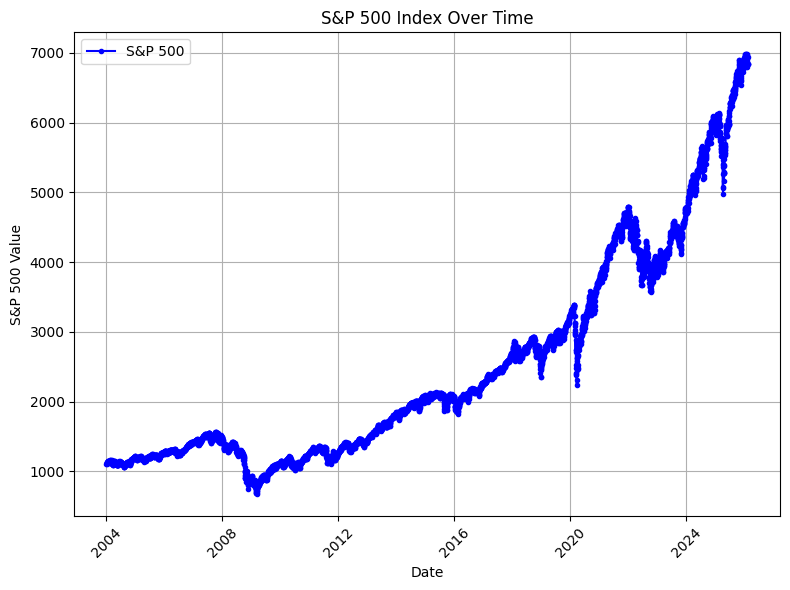

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(df1.index, df1['S&P 500'], marker='.', linestyle='-', color='b', label='S&P 500')
plt.title('S&P 500 Index Over Time')
plt.xlabel('Date')
plt.ylabel('S&P 500 Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


Number of components selected: 7
Mean Absolute Error (MAE): 551.7080
Mean Squared Error (MSE): 421437.6172
R² Score: 0.5319


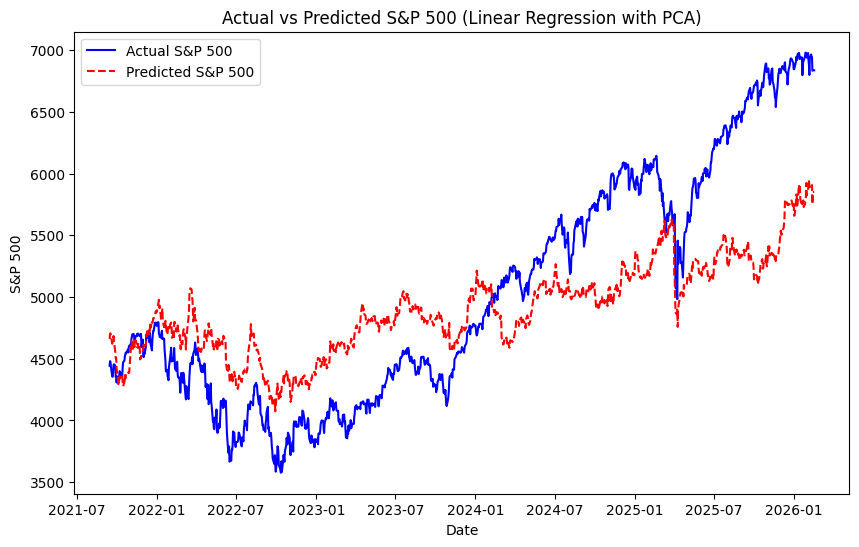

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

df1.index = pd.to_datetime(df1.index)

X = df1.drop(columns=['S&P 500'])  # All columns except S&P 500
y = df1['S&P 500']  # Target variable

train_size = int(len(df1) * 0.80)  # 80% training, 20% testing
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Initialize the Robust Scaler
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA to capture 95% of the variance
pca = PCA(n_components=.95)  # I choose 7 n_components because that was >95% of variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Print the number of components selected
print(f"Number of components selected: {pca.n_components_}")

model = LinearRegression()
model.fit(X_train_pca, y_train)
y_pred1 = model.predict(X_test_pca)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred1)
mse = mean_squared_error(y_test, y_pred1)
r2 = r2_score(y_test, y_pred1)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R² Score: {r2:.4f}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test.index, y_test, label='Actual S&P 500', color='blue')
plt.plot(y_test.index, y_pred1, label='Predicted S&P 500', color='red', linestyle='--')
plt.title('Actual vs Predicted S&P 500 (Linear Regression with PCA)')
plt.xlabel('Date')
plt.ylabel('S&P 500')
plt.legend()
plt.show()

## Ridge regression

Number of components selected: 7

--- Linear Regression Results ---
Mean Absolute Error (MAE): 551.7080
Mean Squared Error (MSE): 421437.6172
Root Mean Squared Error (RMSE): 649.1823
R² Score: 0.5319

Training Neural Network with L2 Regularization (alpha=0.001)...

--- Neural Network Results (with L2 Regularization) ---
Mean Absolute Error (MAE): 399.1866
Mean Squared Error (MSE): 242354.7098
Root Mean Squared Error (RMSE): 492.2953
R² Score: 0.7308
Number of iterations: 100
Final loss: 2175.331542

--- Testing Different L2 Regularization Strengths ---

Training with alpha=0.0001 (L2 regularization)...
  R² Score: 0.7604, MAE: 379.4342, RMSE: 464.4596, Iterations: 100

Training with alpha=0.001 (L2 regularization)...
  R² Score: 0.7308, MAE: 399.1866, RMSE: 492.2953, Iterations: 100

Training with alpha=0.01 (L2 regularization)...
  R² Score: 0.7312, MAE: 398.9915, RMSE: 491.9316, Iterations: 100

Training with alpha=0.1 (L2 regularization)...
  R² Score: 0.7307, MAE: 399.2929, RMSE: 4

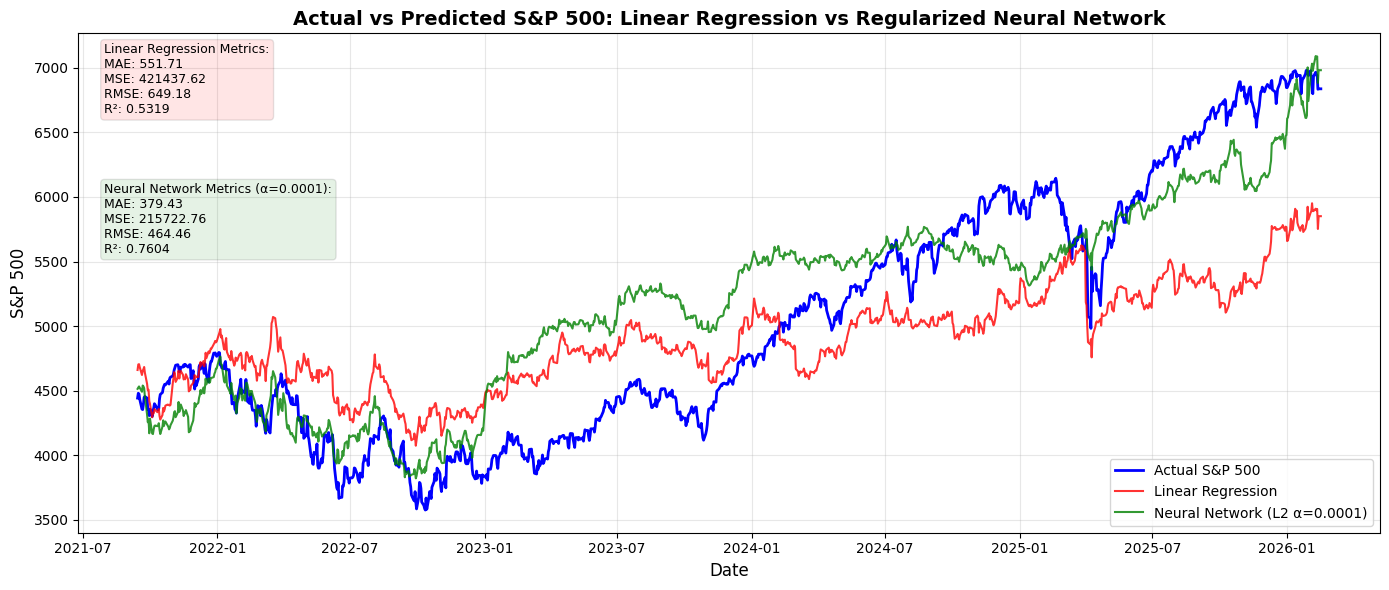

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Assuming df1 is already defined and indexed properly
df1.index = pd.to_datetime(df1.index)

X = df1.drop(columns=['S&P 500'])  # All columns except S&P 500
y = df1['S&P 500']  # Target variable

train_size = int(len(df1) * 0.80)  # 80% training, 20% testing
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Initialize the Robust Scaler
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA to capture 95% of the variance
pca = PCA(n_components=.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Print the number of components selected
print(f"Number of components selected: {pca.n_components_}")

# 1. Linear Regression Model
model_lr = LinearRegression()
model_lr.fit(X_train_pca, y_train)
y_pred_lr = model_lr.predict(X_test_pca)

# Evaluate Linear Regression model
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("\n--- Linear Regression Results ---")
print(f"Mean Absolute Error (MAE): {mae_lr:.4f}")
print(f"Mean Squared Error (MSE): {mse_lr:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.4f}")
print(f"R² Score: {r2_lr:.4f}")

# 2. Neural Network Model with Dropout and L2 Regularization
model_nn = MLPRegressor(
    hidden_layer_sizes=(100, 50, 25),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size='auto',
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=2000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    verbose=False,
)

# Train the neural network
print("\nTraining Neural Network with L2 Regularization (alpha=0.001)...")
model_nn.fit(X_train_pca, y_train)
y_pred_nn = model_nn.predict(X_test_pca)

# Evaluate Neural Network model
mae_nn = mean_absolute_error(y_test, y_pred_nn)
mse_nn = mean_squared_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mse_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print("\n--- Neural Network Results (with L2 Regularization) ---")
print(f"Mean Absolute Error (MAE): {mae_nn:.4f}")
print(f"Mean Squared Error (MSE): {mse_nn:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_nn:.4f}")
print(f"R² Score: {r2_nn:.4f}")
print(f"Number of iterations: {model_nn.n_iter_}")
print(f"Final loss: {model_nn.loss_:.6f}")

# 3. Alternative: Multiple Neural Networks with different regularization strengths
print("\n--- Testing Different L2 Regularization Strengths ---")
alpha_values = [0.0001, 0.001, 0.01, 0.1]
nn_models = {}
nn_predictions = {}
nn_scores = {}

for alpha in alpha_values:
    print(f"\nTraining with alpha={alpha} (L2 regularization)...")
    model_nn_temp = MLPRegressor(
        hidden_layer_sizes=(100, 50, 25),
        activation='relu',
        solver='adam',
        alpha=alpha,
        learning_rate='adaptive',
        max_iter=2000,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        verbose=False
    )

    model_nn_temp.fit(X_train_pca, y_train)
    y_pred_temp = model_nn_temp.predict(X_test_pca)

    r2_temp = r2_score(y_test, y_pred_temp)
    mae_temp = mean_absolute_error(y_test, y_pred_temp)
    mse_temp = mean_squared_error(y_test, y_pred_temp)
    rmse_temp = np.sqrt(mse_temp)

    nn_models[alpha] = model_nn_temp
    nn_predictions[alpha] = y_pred_temp
    nn_scores[alpha] = {'r2': r2_temp, 'mae': mae_temp, 'mse': mse_temp, 'rmse': rmse_temp}

    print(f"  R² Score: {r2_temp:.4f}, MAE: {mae_temp:.4f}, RMSE: {rmse_temp:.4f}, Iterations: {model_nn_temp.n_iter_}")

# Find best alpha based on R² score
best_alpha = max(nn_scores.keys(), key=lambda x: nn_scores[x]['r2'])
best_y_pred_nn = nn_predictions[best_alpha]
best_r2_nn = nn_scores[best_alpha]['r2']
best_mae_nn = nn_scores[best_alpha]['mae']
best_mse_nn = nn_scores[best_alpha]['mse']
best_rmse_nn = nn_scores[best_alpha]['rmse']

print(f"\n--- Best Neural Network (alpha={best_alpha}) ---")
print(f"R² Score: {best_r2_nn:.4f}")
print(f"MAE: {best_mae_nn:.4f}")
print(f"MSE: {best_mse_nn:.4f}")
print(f"RMSE: {best_rmse_nn:.4f}")

# Plot actual vs predicted values for both models with metrics on the plot
fig, ax1 = plt.subplots(figsize=(14, 6))

# Time series comparison
ax1.plot(y_test.index, y_test, label='Actual S&P 500', color='blue', linewidth=2)
ax1.plot(y_test.index, y_pred_lr, label='Linear Regression', color='red', linewidth=1.5, alpha=0.8)
ax1.plot(y_test.index, best_y_pred_nn, label=f'Neural Network (L2 α={best_alpha})', color='green', linewidth=1.5, alpha=0.8)
ax1.set_title('Actual vs Predicted S&P 500: Linear Regression vs Regularized Neural Network', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('S&P 500', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Add metrics text box for Linear Regression
lr_metrics_text = f'Linear Regression Metrics:\nMAE: {mae_lr:.2f}\nMSE: {mse_lr:.2f}\nRMSE: {rmse_lr:.2f}\nR²: {r2_lr:.4f}'
ax1.text(0.02, 0.98, lr_metrics_text, transform=ax1.transAxes,
         fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='red', alpha=0.1))

# Add metrics text box for Neural Network
nn_metrics_text = f'Neural Network Metrics (α={best_alpha}):\nMAE: {best_mae_nn:.2f}\nMSE: {best_mse_nn:.2f}\nRMSE: {best_rmse_nn:.2f}\nR²: {best_r2_nn:.4f}'
ax1.text(0.02, 0.70, nn_metrics_text, transform=ax1.transAxes,
         fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='green', alpha=0.1))

plt.tight_layout()
plt.show()

## The above predictions aren't bad but we need a systematic way to find best model. We need to avoid overfitting

## Lets see if we have overfitting problem! There is a concept called bias variance tradeoff.

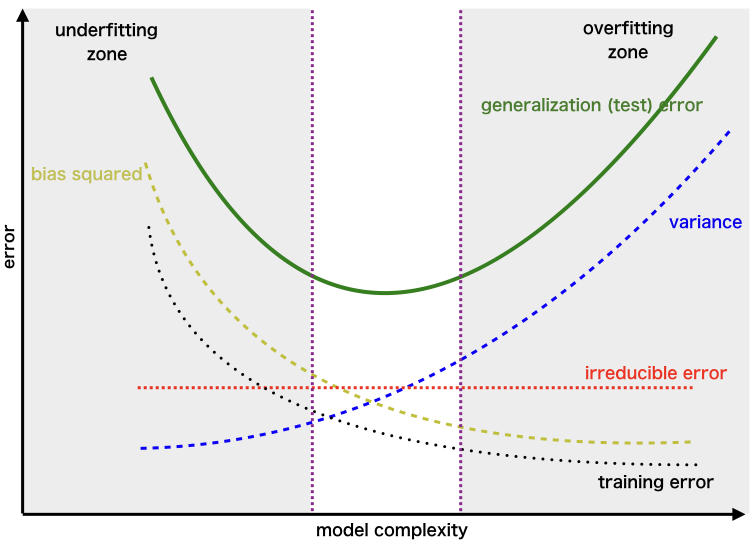

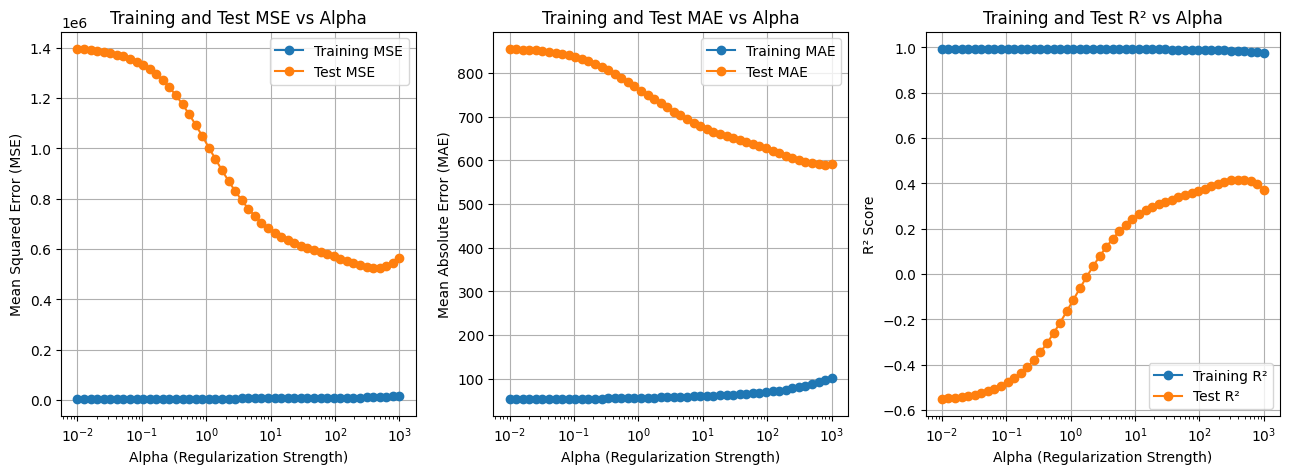

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
X = df1.drop(columns=['S&P 500'])  # All columns except S&P 500
y = df1['S&P 500']  # Target variable

train_size = int(len(df1) * 0.8)  # 80% training, 20% testing
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Initialize the Robust Scaler
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Define a range of alpha (regularization strength) values to test
alphas = np.logspace(-2, 3, 50)  # Alpha values from 0.1 to 100

# Initialize lists to store metrics
train_mse_list, test_mse_list = [], []
train_mae_list, test_mae_list = [], []
train_r2_list, test_r2_list = [], []

# Iterate over each alpha value
for alpha in alphas:
    # Define the Ridge Regression model
    ridge = Ridge(alpha=alpha)

    ridge.fit(X_train_scaled, y_train)
    y_train_pred = ridge.predict(X_train_scaled)
    y_test_pred = ridge.predict(X_test_scaled)
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    # Evaluate the model on the test set
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # Append metrics to lists
    train_mse_list.append(train_mse)
    test_mse_list.append(test_mse)
    train_mae_list.append(train_mae)
    test_mae_list.append(test_mae)
    train_r2_list.append(train_r2)
    test_r2_list.append(test_r2)

# Create subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

# Plot MSE
axes[0].plot(alphas, train_mse_list, label='Training MSE', marker='o')
axes[0].plot(alphas, test_mse_list, label='Test MSE', marker='o')
axes[0].set_xscale('log')  # Use log scale for alpha values
axes[0].set_xlabel('Alpha (Regularization Strength)')
axes[0].set_ylabel('Mean Squared Error (MSE)')
axes[0].set_title('Training and Test MSE vs Alpha')
axes[0].legend()
axes[0].grid()

# Plot MAE
axes[1].plot(alphas, train_mae_list, label='Training MAE', marker='o')
axes[1].plot(alphas, test_mae_list, label='Test MAE', marker='o')
axes[1].set_xscale('log')  # Use log scale for alpha values
axes[1].set_xlabel('Alpha (Regularization Strength)')
axes[1].set_ylabel('Mean Absolute Error (MAE)')
axes[1].set_title('Training and Test MAE vs Alpha')
axes[1].legend()
axes[1].grid()

# Plot R²
axes[2].plot(alphas, train_r2_list, label='Training R²', marker='o')
axes[2].plot(alphas, test_r2_list, label='Test R²', marker='o')
axes[2].set_xscale('log')  # Use log scale for alpha values
axes[2].set_xlabel('Alpha (Regularization Strength)')
axes[2].set_ylabel('R² Score')
axes[2].set_title('Training and Test R² vs Alpha')
axes[2].legend()
axes[2].grid()

# Adjust layout
plt.tight_layout()
plt.show()


## From above code, I believe that the best Regularization for the model is a 100+ alpha.